# PyVIMS

This notebook provide and a set of examples to illustrate the manipulation of Cassini VIMS data in Python with the [`pyvims`](https://pypi.org/project/pyvims/) module.

To install it, please refere to the [project README](https://github.com/seignovert/pyvims).

In [21]:
import matplotlib.pyplot as plt

from pyvims import VIMS

## Getting the data

You do not need to pre-download the VIMS cube to load them in `pyvims`. If the cube is located on a known icy moon of Saturn, and if the file is not present locally, the module will query the VIMS Data Portal from the university of Nantes: [vims.univ-nantes.fr](https://vims.univ-nantes.fr) to retreive the latest calibrated version of the cube. The calibration process is decribed [here](https://vims.univ-nantes.fr/info/isis-calibration). You can also provide your own cubes, if you want.

In [22]:
a ='1536452322_1'
#Titan
cube = VIMS(a)
#Enceladus
#cube = VIMS('1711573513_1')
#Enceladus
#cube = VIMS('1669821191_1')
#DIONE
#cube = VIMS('1649318884_1')
cube

<VIMS> Cube: 1536452322_1
 - Size: (12, 12)
 - Channel: IR
 - Mode: NORMAL
 - Start time: 2006-09-08 23:47:02.728000+00:00
 - Stop time: 2006-09-08 23:47:16.813000+00:00
 - Exposure: 0.08138 sec
 - Duration: 0:00:14.085000
 - Main target: IAPETUS
 - Flyby: 28AT

If you already host some VIMS data locally, you can use the `root=<PATH_FOLDER>` attribute to locate them directly. You can also set the environnement variable `VIMS_DATA` to specify the default `root` value to use. Otherwise, the current working directely will be used.

By default only the infrared channel will be loaded but you can get the visible with the `channel` attribute.

In [23]:

VIMS(a, channel='vis').fname

'C1536452322_1_vis.cub'

## Extract metadata

The `VIMS` object provide a direct access to a subset of the cube metedata.
Here is a list of properties available:

In [24]:
print(f'Cube name: {cube}')
print(f'Filename: {cube.fname}')
print(f'Acquisition start time: {cube.start}')
print(f'Acquisition stop time: {cube.stop}')
print(f'Cube mid-time: {cube.time}')
print(f'Exposure duration: {cube.expo}')
print(f'Channel: {cube.channel}')
print(f'Cube data size: {cube.NB, cube.NL, cube.NS}')
print(f'Acquisition mode: {cube.mode}')
print(f'Main target name: {cube.target_name}')
print(f'Flyby id: {cube.flyby}')

Cube name: 1536452322_1
Filename: C1536452322_1_ir.cub
Acquisition start time: 2006-09-08 23:47:02.728000+00:00
Acquisition stop time: 2006-09-08 23:47:16.813000+00:00
Cube mid-time: 2006-09-08 23:47:09.770500+00:00
Exposure duration: 0.08138
Channel: IR
Cube data size: (256, 12, 12)
Acquisition mode: NORMAL
Main target name: IAPETUS
Flyby id: 28AT


To get the full list of attribute use the `help(cube)` function.

## Extract data

### By band

Extract the image for a specfic band, we should use the `@` operator and provide the band id as an `int`:

In [25]:
cube@167

array([[-9.64118517e-05, -3.65543892e-05, -3.63264335e-05,
        -3.61052043e-05,  6.63977757e-04,  6.60133490e-04,
         6.56413671e-04, -3.52874740e-05,  6.49347203e-04,
        -3.49189359e-05,  6.42778294e-04, -3.45773478e-05],
       [-1.16861025e-04, -1.16115989e-04, -8.22582282e-04,
         5.88195864e-04,  5.84703463e-04, -8.08019890e-04,
        -1.12711321e-04, -1.12094567e-04, -1.11499277e-04,
        -1.10925430e-04, -1.10373061e-04, -7.83017837e-04],
       [-1.96707435e-04, -1.95453831e-04, -1.94236127e-04,
        -8.94921832e-04, -1.91908781e-04, -8.84467387e-04,
        -1.89725746e-04, -1.88688442e-04, -1.87687358e-04,
        -8.65569687e-04, -1.85793993e-04, -1.84901859e-04],
       [ 4.37876937e-04, -2.74617574e-04, -2.72907084e-04,
         4.29747190e-04, -2.69638113e-04, -2.68079777e-04,
        -2.66572315e-04, -2.65115872e-04, -2.63710419e-04,
         4.15660674e-04,  4.13596135e-04,  4.11613029e-04],
       [ 3.57586861e-04, -3.53656040e-04,  3.5309590

### By wavelength

The same apply for a specific wavelength but this time you should use a `float`:

In [26]:
cube@2.03

array([[-9.64118517e-05, -3.65543892e-05, -3.63264335e-05,
        -3.61052043e-05,  6.63977757e-04,  6.60133490e-04,
         6.56413671e-04, -3.52874740e-05,  6.49347203e-04,
        -3.49189359e-05,  6.42778294e-04, -3.45773478e-05],
       [-1.16861025e-04, -1.16115989e-04, -8.22582282e-04,
         5.88195864e-04,  5.84703463e-04, -8.08019890e-04,
        -1.12711321e-04, -1.12094567e-04, -1.11499277e-04,
        -1.10925430e-04, -1.10373061e-04, -7.83017837e-04],
       [-1.96707435e-04, -1.95453831e-04, -1.94236127e-04,
        -8.94921832e-04, -1.91908781e-04, -8.84467387e-04,
        -1.89725746e-04, -1.88688442e-04, -1.87687358e-04,
        -8.65569687e-04, -1.85793993e-04, -1.84901859e-04],
       [ 4.37876937e-04, -2.74617574e-04, -2.72907084e-04,
         4.29747190e-04, -2.69638113e-04, -2.68079777e-04,
        -2.66572315e-04, -2.65115872e-04, -2.63710419e-04,
         4.15660674e-04,  4.13596135e-04,  4.11613029e-04],
       [ 3.57586861e-04, -3.53656040e-04,  3.5309590

__Note:__ For now, the wavelength are not interpolated on the channels wavelengths. The output image correspond to the closes wavelength

### Alternative notations

Alternatively, you can also use the array index notation `[]` instead of the `@` symbol:

In [27]:
cube[167]

array([[-9.64118517e-05, -3.65543892e-05, -3.63264335e-05,
        -3.61052043e-05,  6.63977757e-04,  6.60133490e-04,
         6.56413671e-04, -3.52874740e-05,  6.49347203e-04,
        -3.49189359e-05,  6.42778294e-04, -3.45773478e-05],
       [-1.16861025e-04, -1.16115989e-04, -8.22582282e-04,
         5.88195864e-04,  5.84703463e-04, -8.08019890e-04,
        -1.12711321e-04, -1.12094567e-04, -1.11499277e-04,
        -1.10925430e-04, -1.10373061e-04, -7.83017837e-04],
       [-1.96707435e-04, -1.95453831e-04, -1.94236127e-04,
        -8.94921832e-04, -1.91908781e-04, -8.84467387e-04,
        -1.89725746e-04, -1.88688442e-04, -1.87687358e-04,
        -8.65569687e-04, -1.85793993e-04, -1.84901859e-04],
       [ 4.37876937e-04, -2.74617574e-04, -2.72907084e-04,
         4.29747190e-04, -2.69638113e-04, -2.68079777e-04,
        -2.66572315e-04, -2.65115872e-04, -2.63710419e-04,
         4.15660674e-04,  4.13596135e-04,  4.11613029e-04],
       [ 3.57586861e-04, -3.53656040e-04,  3.5309590

In that case, you can also average multiply channels at once (here between 4.9 and 5.1 µm):

In [28]:
cube[4.9:5.1]

array([[ 0.00437032, -0.00011712, -0.0012012 ,  0.00036957, -0.0012634 ,
        -0.00053383, -0.00112973,  0.00410445, -0.00017413,  0.00131292,
         0.00095741, -0.00257433],
       [-0.00237264, -0.00046721, -0.00270974, -0.00370671,  0.00031224,
        -0.00125029, -0.00036174, -0.00360824, -0.00085663, -0.00070226,
         0.00106559, -0.00119553],
       [ 0.00021437, -0.00078685, -0.00073279, -0.00158771,  0.00100777,
        -0.00233185, -0.00260167, -0.00320033, -0.00260566, -0.00093262,
        -0.00145408, -0.00107909],
       [-0.0004023 , -0.00023763, -0.00284647, -0.00364679,  0.0001139 ,
        -0.00255268, -0.00072163, -0.00305161,  0.00124565,  0.00054809,
        -0.00160808,  0.00076193],
       [-0.00062492, -0.00286056,  0.00027425,  0.00025926, -0.00094547,
         0.00121701,  0.00150148, -0.00548142, -0.00351641, -0.00185577,
        -0.00190157, -0.00105847],
       [-0.00324815, -0.00075422, -0.00156637, -0.00532637, -0.00203881,
         0.00033067,  

Finally, if you provide 3 argument, you will get a 3D array `(NL, NS, 3)`to make RGB composite:

In [29]:
cube[2.03, 1.58, 2.79].shape

(12, 12, 3)

The alternative operation with the `@` symbol will require to add `'i:j'` around each channel:

In [30]:
img = cube@('165:169', '138:141', '212:213')
img.shape

(12, 12, 3)

### Pixel spectrun

To extract a specific pixel, you need to provide the pixel coordinates as `[S, L]`:

In [37]:
cube[12, 12]

<VIMSPixel> 1536452322_1-S12_L12
 - Sample: 12
 - Line: 12
 - Lon: 74°E
 - Lat: 64°N
 - Alt: 12724 km (Limb pixel)

__Note:__ The VIMS, the first pixel is `[1, 1]` located on the top left corner and the last pixel is at `[NS, NL]` on the bottom right corner.

The `tuple` index notation also works:

In [38]:
pixel = cube@(2, 2)

Each VIMS pixel object contains its spectrum and its geographic information as attributes:

In [39]:
pixel.spectrum.shape, pixel.spectrum[0], pixel.lon, pixel.lat, pixel.inc, pixel.eme, pixel.phase

((256,),
 np.float32(-0.00044309557),
 np.float64(106.0165037402086),
 np.float64(-69.79520086010506),
 np.float64(90.85068892516745),
 np.float64(90.0000000000054),
 np.float64(2.0590533659818))

If you try to access a pixel outsite the range available, an `VIMSError` will be throw:

In [40]:
from pyvims.errors import VIMSError

try:
    pixel = cube[1, 100]
except VIMSError as err:
    print(err)

Line must be between `1` and `12`.


## Plot cube

### Plot image

Based on the previous section, you can perform cube various plots based on the cube data. You can change the contrast (vmin and vmax) to better see the object.

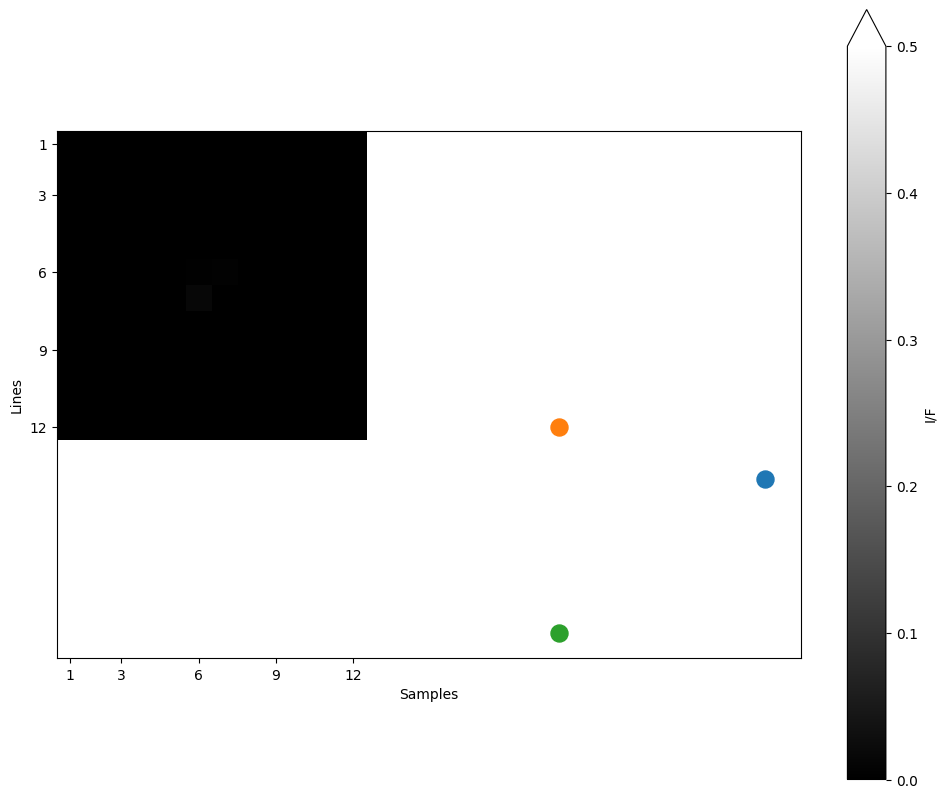

In [41]:
plt.figure(figsize=(12, 10))

plt.imshow(cube@2.03, extent=cube.extent, cmap='gray', vmin=0, vmax=.5)

plt.colorbar(extend='max', label='I/F')

#you can place few points on the object to choose which VIMS spectra you would like to visualise
plt.scatter(28, 14, s=150)
plt.scatter(20, 12, s=150)
plt.scatter(20, 20, s=150)

plt.xlabel(cube.slabel)
plt.ylabel(cube.llabel)

plt.xticks(cube.sticks)
plt.yticks(cube.lticks);

__Note__: If you overplot data on the image, it is highly recommanded to add the `extent` attribute in the `imshow` function to display the image between `[1, 1]` and `[NS, NL]` and not between `[0, 0]` and `[NS-1, NL-1]` as python do by default.

Some shortcuts are also available to add nice ticks and labels.

### Plot spectra

You can also plot cube spectra for the previously labeled pixels (with some offsets):

In [42]:
plt.figure(figsize=(15, 6))

plt.plot(cube.wvlns, cube[28, 14].spectrum + .000, '-', label='Pixel (20, 15)')
plt.plot(cube.wvlns, cube[20, 12].spectrum + .000, '-', label='Pixel (28, 13)')
plt.plot(cube.wvlns, cube[20, 20].spectrum + .000, '-', label='Pixel (20, 24)')

plt.legend()

plt.xlabel(cube.wlabel)
plt.ylabel(cube.ilabel)

plt.xticks(cube.wticks);

VIMSError: Sample must be between `1` and `12`.

<Figure size 1500x600 with 0 Axes>

## Cube projections

VIMS-IR is a 2D mirror scanning instrument (1D for VIMS-VIS), therefore the image recorded is not instantaneous acuisition. Each individual pixel neeed to be projected on the targeted body frame to reconstruct a consistant image. In order to make this manipulation more easily, we implemented a collection of a few usefull projection.


### Sky projection

It correspond to the pixel pointing orientation in sky coordinates (right-ascension and declination).

This projection can be used to make star detection based on their coordinates.

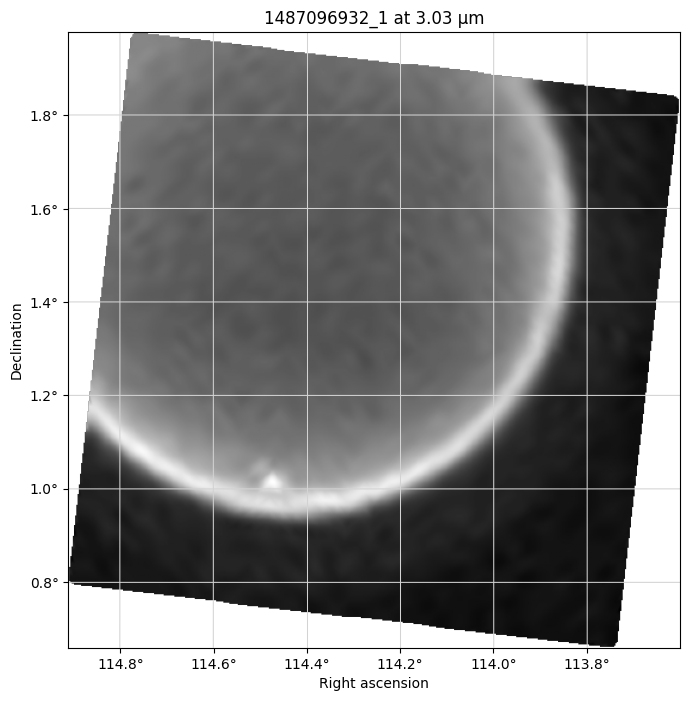

In [ ]:
cube.plot(3.03, 'sky');

__Note:__ If the spacecraft move too much during the acquisition the actual data may produce a distorded image.

### Orthographic projection

This projection correspond to the smallest, non distorded representation of the cube.
It provides the best way to add geographic grid coordinate on the image.
The projection is made in the mean observation plane of the observation.

Here, we use the RGB notation to get a colored image:

In [ ]:
cube.plot(('339:351', '138:141', '121:122'), 'ortho');